# Task 1 - Binary Classification Model : Model Engineering and optimisation

### Motivation 

Having found and tested a suitable baseline or my data processing, being augmentation with a mix of hashing, downsampling and using class weights, an investigation into the most efficient and accurate model will be shown in this notebook. This will produce the most time and computer memory effective model as possible providing a novel alternative to standard library models produced and used in climate science fields.

### Main focuses of this Notebook

This notebook specifically covers the model optimisations of the Binary Fire vs No Fire classifier. The hyperparameters of the various model iterations will be justified, alongside optimisers. Various loss functions will be tested from inbuilt tensorflow basics to novel functions. A final comparison will be made to well established backbone models such as EfficientNetV2.

### Steps followed

* model size variation will be evaluated to see the effect diffrent layering sizes and layer types have on the outcome of the model, accuracy and time wise
* A novel Focal loss function will be tested to see if the newly balanced datasets gain performance with a loss function which incoperates weighting. 
* comparison to EfficientNetV2 to see the shortcomes of my hand tuned model, with the use of Keras Tuner at the end to find the most optimal model and accuracy for the given data

### Summary

The goal for this notebook is to make the most efficient and accurate model possible while exploring what leads to it.

In [ ]:
# import necessary libraries

import numpy as np
import sklearn
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import os
from PIL import Image
import imagehash
import imageio.v3 as imageio
import pandas as pd
import seaborn as sns
from collections import Counter
import random
import keras_tuner as kt

# setting global parameters for the experiments
Image_size = 96
Batch = 32
Random_seed = 42

The below cells are a copy and paste of the exploratory work done in the previous notebook, I repeat the Image hash, augmentations and class weight functions. Then I define the train test and validation data sets and run a sizeable model to get a baseline performance.

In [ ]:
def get_clean_data_ImageHash(dirs):
    ''' Load image paths and labels from the given directories, 
    compute perceptual hashes to identify and remove duplicates, 
    and return the cleaned lists of paths and labels.'''

    # iterate through the directories and class subdirectories to collect all image paths and labels
    all_paths, all_labels = [], []
    for d in dirs:

        # get class names and assign integer labels, then collect file paths for each class
        class_names = sorted(os.listdir(d))
        class_to_idx = {name: i for i, name in enumerate(class_names)}
        for class_name in class_names:

            # construct the class path and check if it's a directory, then list all files and extend the paths and labels lists
            c_path = os.path.join(d, class_name)
            if not os.path.isdir(c_path): continue
            files = [os.path.join(c_path, f) for f in os.listdir(c_path)]
            all_paths.extend(files)
            all_labels.extend([class_to_idx[class_name]] * len(files))
    
    # compute perceptual hashes for all images
    unique_hashes = {}
    clean_paths, clean_labels = [], []
    print(f"Total raw files: {len(all_paths)}")

    # keep only unique hashes to filter out duplicates
    for p, l in zip(all_paths, all_labels):
        try:
            with Image.open(p) as img:
                h = str(imagehash.phash(img))
                if h not in unique_hashes:
                    unique_hashes[h] = p
                    clean_paths.append(p)
                    clean_labels.append(l)
        except: continue
    print(f"Total unique files: {len(clean_paths)}")
    return clean_paths, clean_labels


def balance_split(paths, labels):
    ''' Balance the dataset by undersampling the majority class to match the count of the minority class.'''

    # compute the count of samples for each class, shuffle the combined list of paths and labels
    counts = Counter(labels)
    min_count = min(counts.values())
    combined = list(zip(paths, labels))
    random.shuffle(combined)
    bal_p, bal_l = [], []
    class_seen = Counter()
    # iterate through the combined list of paths and labels, and keep only min_count samples for each class to create a balanced dataset
    for p, l in combined:
        if class_seen[l] < min_count:
            bal_p.append(p)
            bal_l.append(l)
            class_seen[l] += 1
    return bal_p, bal_l


def apply_blur(img):
    ''' Apply a simple average blur to the input image to simulate 
        motion blur or out of focus blur.'''

    img = tf.expand_dims(img, 0)
    img = tf.nn.avg_pool2d(img, ksize=3, strides=1, padding='SAME')
    return tf.squeeze(img, 0)

def augment(image, label):
    ''' Apply random augmentations to the input image to increase the 
    diversity of the training data and improve model robustness.'''

    # normalize to [0,1] and apply random flips, rotations, brightness/contrast/saturation/hue adjustments
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.rot90(image, k=tf.random.uniform((), 0, 4, dtype=tf.int32))
    image = tf.image.random_brightness(image, max_delta=0.3)
    image = tf.image.random_contrast(image, lower=0.7, upper=1.4)
    image = tf.image.random_saturation(image, lower=0.6, upper=1.6)
    image = tf.image.random_hue(image, max_delta=0.05)
    
    # add random haze effect by blending the image with a light gray haze
    haze_intensity = tf.random.uniform((), 0.05, 0.25)
    haze = tf.ones_like(image) * 0.7

    # randomly apply the haze effect to some images to simulate different weather conditions
    image = tf.cond(
        tf.random.uniform(()) > 0.5,
        lambda: image * (1 - haze_intensity) + haze * haze_intensity,
        lambda: image
    )

    # randomly apply a blur effect to some images to simulate motion blur or out of focus blur
    image = tf.cond(
        tf.random.uniform(()) > 0.6,
        lambda: apply_blur(image),
        lambda: image
    )

    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label


def normalize(image, label):
    ''' Normalize the input image to [0,1] range for better training stability.'''
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def load_and_preprocess(path, label):
    ''' Load the image from the given path and preprocess it by resizing to the target size.'''
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [Image_size, Image_size])
    return img, label

def prepare_dataset(paths, labels, use_aug=False, shuffle=True):
    ''' Prepare a tf.data.Dataset from the given image paths and labels, 
    with optional augmentation and shuffling.'''

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    # shuffle the dataset if specified to improve training randomness and generalization
    if shuffle:
        ds = ds.shuffle(len(paths))
    ds = ds.map(load_and_preprocess)
    if use_aug:
        ds = ds.map(augment)
    ds = ds.map(normalize).batch(Batch).prefetch(tf.data.AUTOTUNE)
    return ds

# load and clean the data using perceptual hashing to remove duplicates
all_p, all_l = get_clean_data_ImageHash(["Training_Bi/", "Test/"])

# split into training and validation/test sets with stratification 
tr_p, temp_p, tr_l, temp_l = train_test_split(
    all_p, all_l, test_size=0.25, random_state=Random_seed, stratify=all_l
)
val_p, te_p, val_l, te_l = train_test_split(
    temp_p, temp_l, test_size=0.5, random_state=Random_seed, stratify=temp_l
)

Total raw files: 47992
Total unique files: 12691


In [ ]:
# loading the data sets into tf.data.Dataset objects with appropriate preprocessing, augmentation for training set, and normalization for validation/test sets
train_ds = (tf.data.Dataset.from_tensor_slices((tr_p, tr_l))
            .shuffle(len(tr_p)).map(load_and_preprocess).map(augment).batch(Batch).prefetch(2))
val_ds = (tf.data.Dataset.from_tensor_slices((val_p, val_l))
          .map(load_and_preprocess).map(normalize).batch(Batch).prefetch(2))
test_ds = (tf.data.Dataset.from_tensor_slices((te_p, te_l))
           .map(load_and_preprocess).map(normalize).batch(Batch).prefetch(2))



def compute_class_weights(ds):
    ''' Compute class weights based on the distribution of labels in 
    the dataset to handle class imbalance.'''

    # extract labels from the dataset and compute class weights using inverse frequency
    labels = np.array([y.numpy() for _, y in ds])
    counts = np.bincount(labels)
    total = len(labels)
    weights = {i: total / (len(counts) * c) for i, c in enumerate(counts)}
    print(f"Class weights: {weights}")
    return weights

# class weights
weights = compute_class_weights('balanced', classes=np.unique(tr_l), y=tr_l)
class_weights = dict(enumerate(weights))

### Larger model

The model below is a large model, with around 7 million parameters. It incoperates Conv2D layers for image processing and dropout layers to prevent overfitting. sigmoid layer is used at the end to produce a binary classification model. max pooling and average pooling is used to reduce spatial dimensions 

Notice intitally downsampling isnt used. This is to show the progession of my work, as intially I only used strong weighting. A comparison of using downsampling to using weights and various loss functions is discussed further down.

In [ ]:
model = keras.models.Sequential([
    keras.layers.Conv2D(4, 3, activation='relu', padding='same'),
    keras.layers.Conv2D(4, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling2D(),
    keras.layers.Dropout(0.1),

    keras.layers.Conv2D(8, 3, activation='relu', padding='same'),
    keras.layers.Conv2D(8, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling2D(),
    keras.layers.Dropout(0.2),
    keras.layers.Conv2D(16, 3, activation='relu', padding='same'),
    keras.layers.Conv2D(16, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling2D(),
    keras.layers.Dropout(0.2),
    keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
    keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling2D(),
    keras.layers.Dropout(0.3),
    keras.layers.Conv2D(64, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling2D(),
    keras.layers.Dropout(0.4),
    keras.layers.Conv2D(128, 3, activation='relu', padding='same'),
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation='sigmoid')
])

In [ ]:
# running the model with binary cross entropy
model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss = 'binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Recall(name='recall'),
        keras.metrics.Precision(name='precision'),
    ]
)

#fitting the model
history = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    class_weight=class_weights,
)

Epoch 1/10
298/298 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.6574 - loss: 0.6287 - precision: 0.6504 - recall: 0.4778 - val_accuracy: 0.7945 - val_loss: 0.4795 - val_precision: 0.8163 - val_recall: 0.6877
Epoch 2/10
298/298 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7686 - loss: 0.5049 - precision: 0.8143 - recall: 0.6140 - val_accuracy: 0.8014 - val_loss: 0.4536 - val_precision: 0.8777 - val_recall: 0.6375
Epoch 3/10
298/298 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7813 - loss: 0.4891 - precision: 0.8329 - recall: 0.6288 - val_accuracy: 0.8064 - val_loss: 0.4338 - val_precision: 0.9278 - val_recall: 0.6074
Epoch 4/10
298/298 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7925 - loss: 0.4673 - precision: 0.8363 - recall: 0.6567 - val_accuracy: 0.8064 - val_loss: 0.4317 - val_precision: 0.9297 - val_recall: 0.6060
Epoch 5/10
298/298 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7937 - loss: 0.4661 - precision: 0.8369 - recall: 0.6593 - val_accuracy: 0.8197 - val_los

In [ ]:
# plotting training history

loss, acc, recall, precision = model.evaluate(test_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {acc:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test Precision: {precision:.4f}")

y_pred_prob = model.predict(test_ds)

true_labels = np.concatenate([y.numpy() for _, y in test_ds])

pred_classes = (y_pred_prob > 0.50).astype(int).flatten()
cm = confusion_matrix(true_labels, pred_classes)
print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(true_labels, pred_classes, target_names=['No_Fire', 'Fire']))

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8015 - loss: 0.4227 - precision: 0.7070 - recall: 0.9370
Test Loss: 0.4227
Test Accuracy: 0.8015
Test Recall: 0.9370
Test Precision: 0.7070
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Confusion Matrix:
[[618 271]
 [ 44 654]]

Classification Report:
              precision    recall  f1-score   support

     No_Fire       0.93      0.70      0.80       889
        Fire       0.71      0.94      0.81       698

    accuracy                           0.80      1587
   macro avg       0.82      0.82      0.80      1587
weighted avg       0.83      0.80      0.80      1587



The model seems to be reasonable, getting modest recall and good F1 scores. However this model is very large, taking a long time to run and Fire Biased as identified by the confusion matrix. This is a result of the unbalanced data. To evaluate the effect of the model size, the below code defines a function that tries multiple models and various dropout values. 

The models vary from 'very small' to 'large', to lously display the size of model and run time compared to the origional model displayed above.

In [ ]:
def build_binary_model_scaled_adv(model_size='medium', loss_fn=None):   
    ''' Build a binary classification model with scalable architecture 
    based on the specified model size (very_small, small, medium, large) and optional loss function.'''

    # model configurations 
    scales = {
        'very_small': (3, 8, 16),   
        'small':      (4, 16, 32),  
        'medium':     (5, 16, 64),  
        'large':      (5, 32, 128), 
    }
    
    # select the configuration based on the model size and unpack the parameters
    num_blocks, base_filters, dense_dim = scales[model_size]

    
    # building the model
    model = keras.models.Sequential()
    model.add(keras.layers.Input(shape=(96, 96, 3)))

    for i in range(num_blocks):
        # calculating number of filters for the current block by exponentially increasing based on the block index
        filters = base_filters * (2**i)
        model.add(keras.layers.Conv2D(filters, 3, activation='relu', padding='same'))
        model.add(keras.layers.MaxPooling2D())
        model.add(keras.layers.Dropout(0.2 if i < 2 else 0.3))

    model.add(keras.layers.Conv2D(filters * 2, 3, activation='relu', padding='same'))
    model.add(keras.layers.GlobalAveragePooling2D())
    model.add(keras.layers.Dense(dense_dim, activation='relu'))
    model.add(keras.layers.Dropout(0.2))
    model.add(keras.layers.Dense(1, activation='sigmoid'))

    # compiling the model
    model.compile(
        optimizer=keras.optimizers.Adam(1e-4),
        loss=loss_fn if loss_fn else 'binary_crossentropy',
        metrics=['accuracy', keras.metrics.Precision(name='precision'), keras.metrics.Recall(name='recall')]
    )
    return model

def run_binary_experiment(size, loss_func, weights, callbacks):
    ''' Run a training experiment for the binary classification model with the specified size, loss function, class weights, and callbacks.'''

    print(f"\n--- TESTING BINARY {size.upper()} ---")
    model = build_binary_model_scaled_adv(size, loss_func)
    history = model.fit(train_ds, validation_data=val_ds, epochs=30, 
                        class_weight=weights, callbacks=callbacks, verbose=1)
    
    # evaluate the model on the test set and print the results
    metrics = ['loss', 'accuracy', 'precision', 'recall']
    plt.figure(figsize=(20, 5))
    for i, metric in enumerate(metrics):
        plt.subplot(1, 4, i+1)
        plt.plot(history.history[metric], label='Train')
        plt.plot(history.history[f'val_{metric}'], label='Val')
        plt.title(f'{size} {metric}')
        plt.legend()
    plt.show()
    return model, history



--- TESTING BINARY VERY_SMALL ---
Epoch 1/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.5982 - loss: 0.6820 - precision: 0.6639 - recall: 0.1751 - val_accuracy: 0.4868 - val_loss: 0.6850 - val_precision: 0.4608 - val_recall: 0.9771
Epoch 2/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7001 - loss: 0.6217 - precision: 0.6758 - recall: 0.6116 - val_accuracy: 0.7093 - val_loss: 0.5920 - val_precision: 0.6348 - val_recall: 0.7994
Epoch 3/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7214 - loss: 0.5709 - precision: 0.6861 - recall: 0.6756 - val_accuracy: 0.7579 - val_loss: 0.5415 - val_precision: 0.7224 - val_recall: 0.7307
Epoch 4/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7440 - loss: 0.5366 - precision: 0.7233 - recall: 0.6768 - val_accuracy: 0.7264 - val_loss: 0.5526 - val_precision: 0.6538 - val_recall: 0.8037
Epoch 5/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7527 - loss: 0.5249 - precision: 0.7445 - recall: 0.66

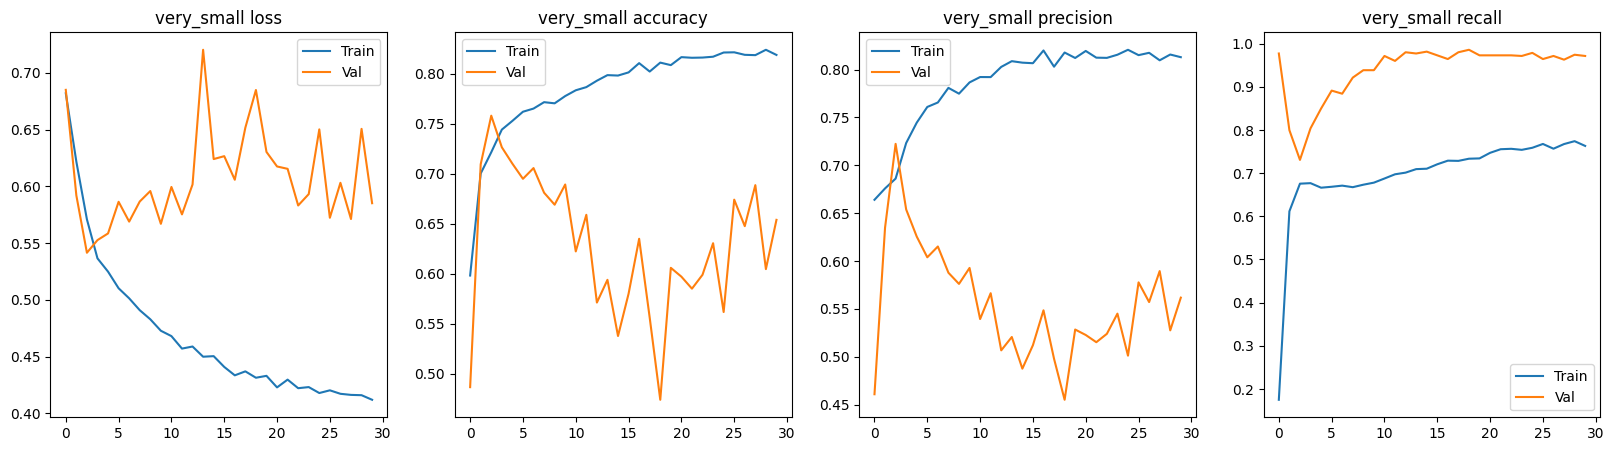


--- TESTING BINARY SMALL ---
Epoch 1/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.6109 - loss: 0.6627 - precision: 0.6398 - recall: 0.2640 - val_accuracy: 0.6274 - val_loss: 0.6633 - val_precision: 0.5448 - val_recall: 0.9327
Epoch 2/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.7670 - loss: 0.5122 - precision: 0.7723 - recall: 0.6667 - val_accuracy: 0.5738 - val_loss: 0.8983 - val_precision: 0.5083 - val_recall: 0.9670
Epoch 3/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.7820 - loss: 0.4766 - precision: 0.7869 - recall: 0.6916 - val_accuracy: 0.6021 - val_loss: 0.8120 - val_precision: 0.5260 - val_recall: 0.9699
Epoch 4/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.7872 - loss: 0.4553 - precision: 0.7853 - recall: 0.7105 - val_accuracy: 0.5095 - val_loss: 1.0640 - val_precision: 0.4726 - val_recall: 0.9871
Epoch 5/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.8031 - loss: 0.4289 - precision: 0.7976 - recall: 0.7401 - 

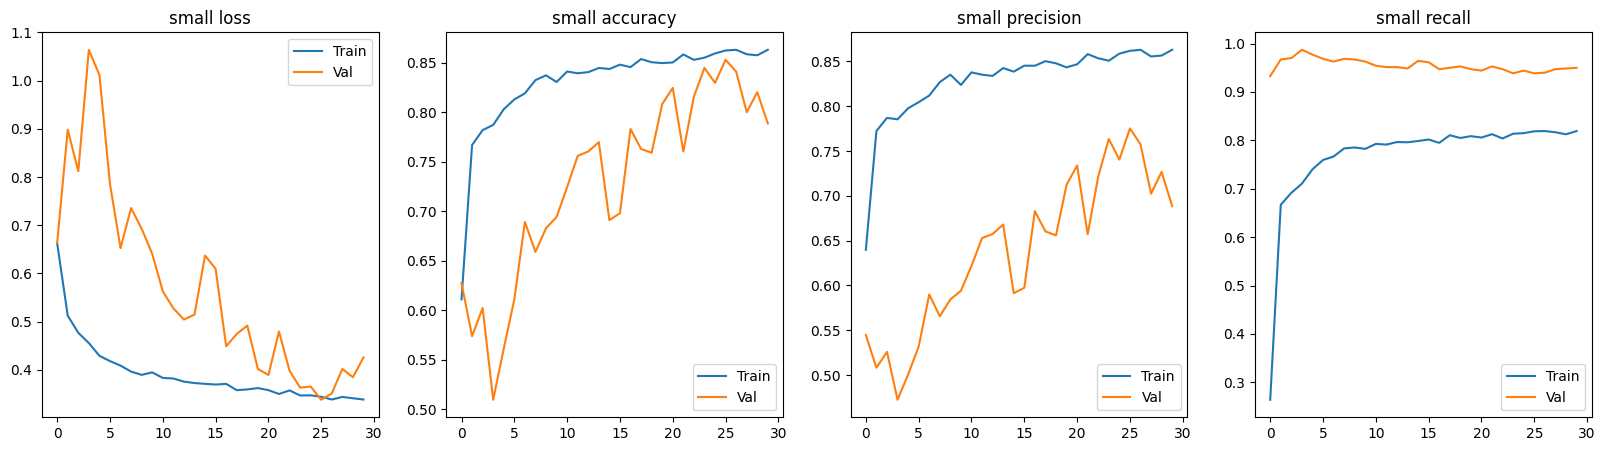


--- TESTING BINARY MEDIUM ---
Epoch 1/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.6701 - loss: 0.6194 - precision: 0.7102 - recall: 0.4221 - val_accuracy: 0.7093 - val_loss: 0.5698 - val_precision: 0.6287 - val_recall: 0.8295
Epoch 2/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.7797 - loss: 0.4865 - precision: 0.7950 - recall: 0.6725 - val_accuracy: 0.7289 - val_loss: 0.5755 - val_precision: 0.6351 - val_recall: 0.9026
Epoch 3/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.7907 - loss: 0.4530 - precision: 0.7949 - recall: 0.7064 - val_accuracy: 0.7667 - val_loss: 0.5329 - val_precision: 0.6701 - val_recall: 0.9255
Epoch 4/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.8123 - loss: 0.4169 - precision: 0.8076 - recall: 0.7523 - val_accuracy: 0.6734 - val_loss: 0.7158 - val_precision: 0.5777 - val_recall: 0.9585
Epoch 5/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.8264 - loss: 0.4003 - precision: 0.8232 - recall: 0.7709 

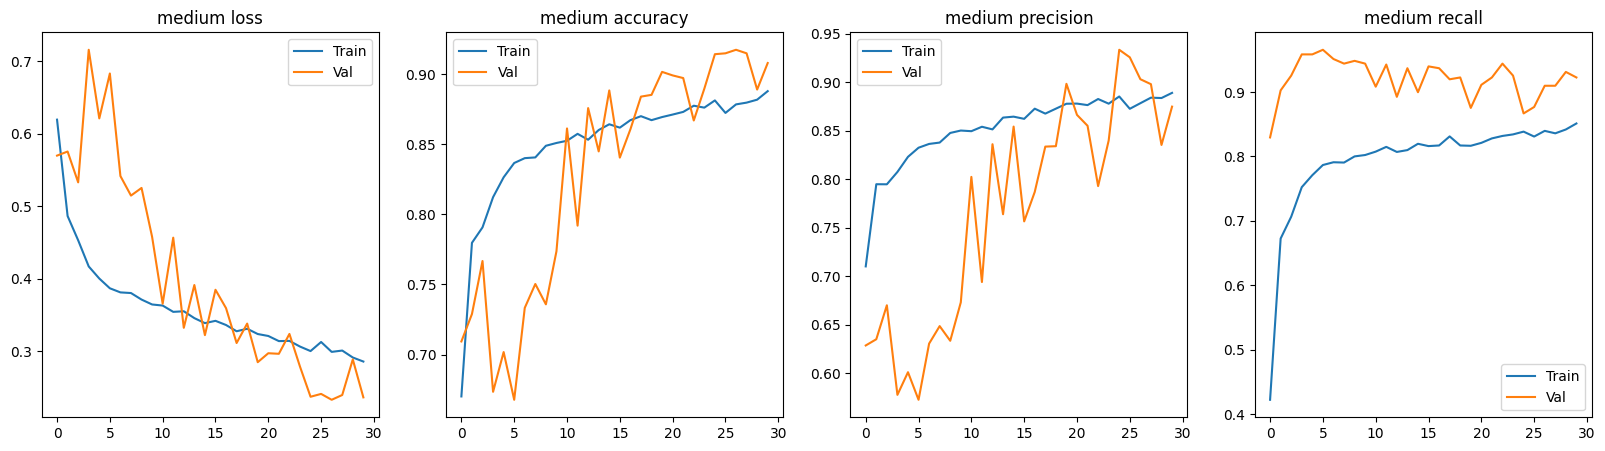


--- TESTING BINARY LARGE ---
Epoch 1/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 29s 94ms/step - accuracy: 0.7102 - loss: 0.5657 - precision: 0.7457 - recall: 0.5177 - val_accuracy: 0.5712 - val_loss: 0.9070 - val_precision: 0.5067 - val_recall: 0.9685
Epoch 2/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 41s 93ms/step - accuracy: 0.7958 - loss: 0.4525 - precision: 0.8022 - recall: 0.7109 - val_accuracy: 0.4641 - val_loss: 1.5902 - val_precision: 0.4506 - val_recall: 0.9928
Epoch 3/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 41s 93ms/step - accuracy: 0.8134 - loss: 0.4226 - precision: 0.8065 - recall: 0.7575 - val_accuracy: 0.5694 - val_loss: 1.2390 - val_precision: 0.5056 - val_recall: 0.9771
Epoch 4/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 28s 94ms/step - accuracy: 0.8329 - loss: 0.3873 - precision: 0.8224 - recall: 0.7910 - val_accuracy: 0.5536 - val_loss: 1.1897 - val_precision: 0.4964 - val_recall: 0.9828
Epoch 5/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 28s 93ms/step - accuracy: 0.8432 - loss: 0.3782 - precision: 0.8369 - recall: 0.79

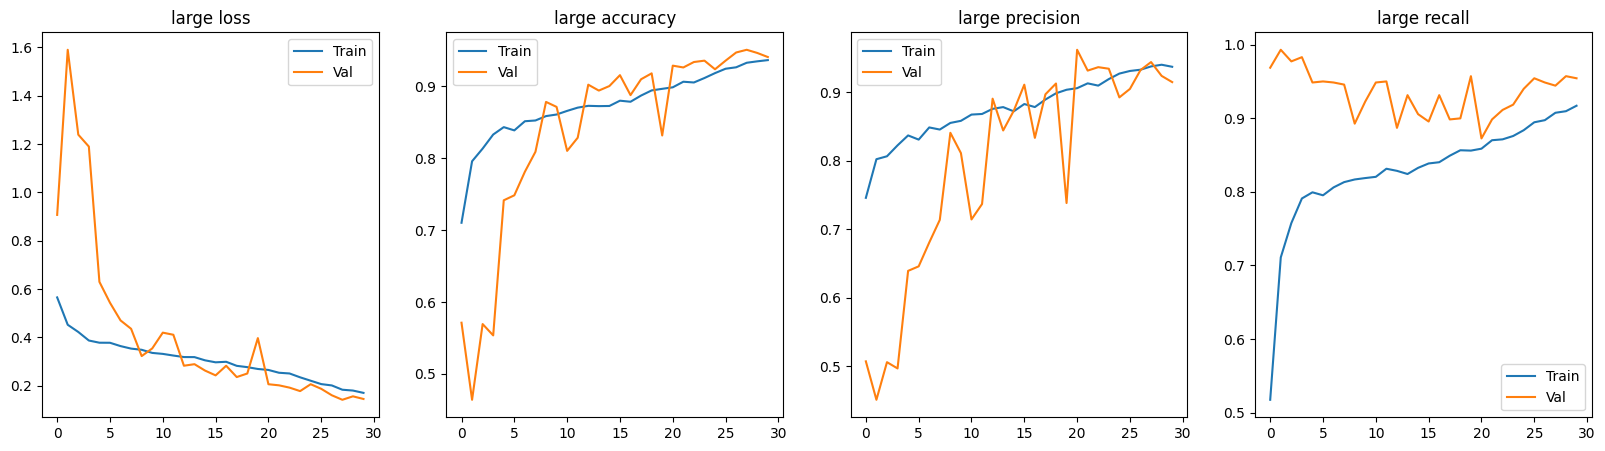

In [ ]:
# running with class weights and binary cross entropy loss for different model sizes
all_results = {}
for model_size in ['very_small', 'small', 'medium', 'large']:
    all_results[model_size] = run_binary_experiment(model_size, None, class_weights, None)

A noticable trend already is that, despite generally having higher accuracies, the larger models take exponentially longer to run. To investigate this I produce a plotting function below.

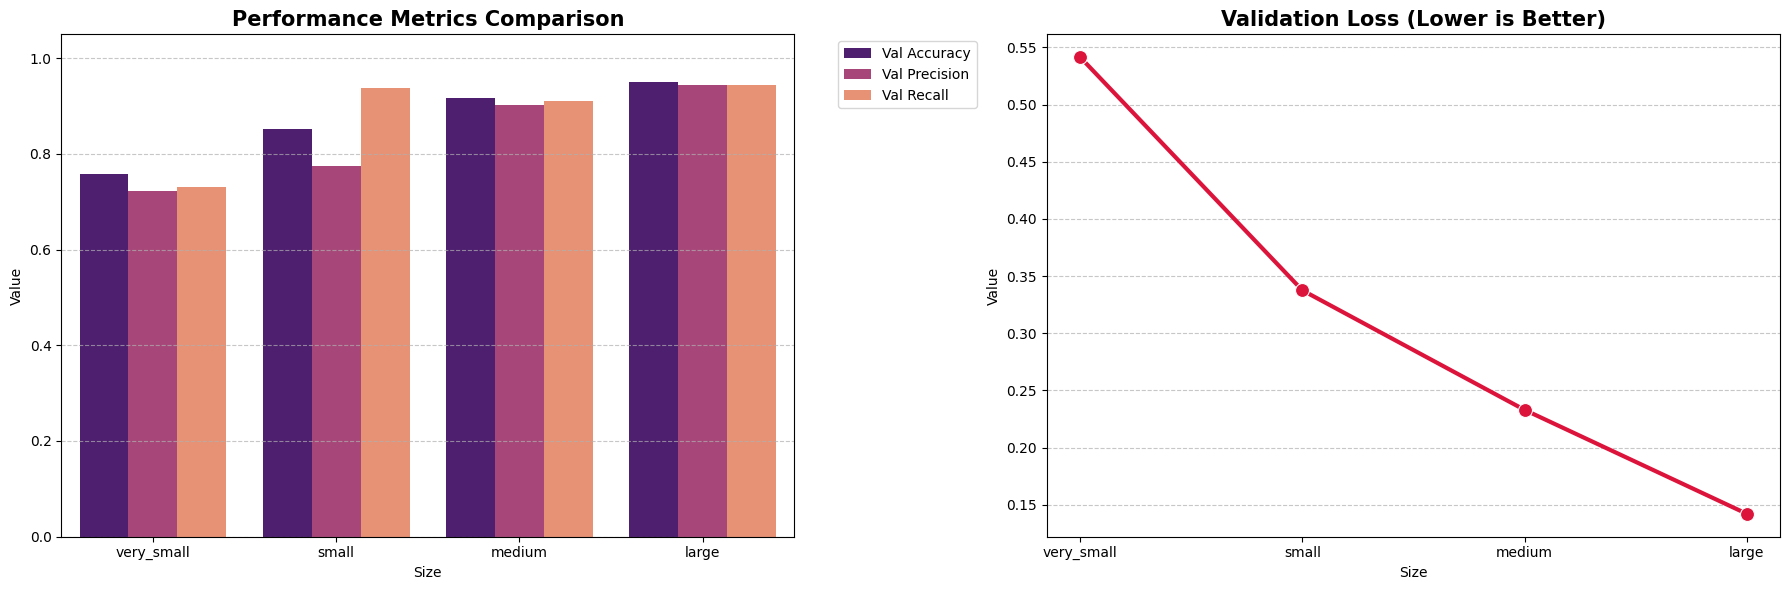

In [ ]:

def plot_model_comparison(results_dict):
    ''' Plot a comparison of the performance metrics (accuracy, precision, recall) for different model sizes based on the training history results.'''

    data = []

    # iterate through the results dictionary to extract the best validation metrics for each model size 
    for size, result in results_dict.items():
        if isinstance(result, tuple):
            history_obj = result[1]
        else:
            history_obj = result
        # extract the history dictionary from the history object
        h_dict = history_obj.history if hasattr(history_obj, 'history') else history_obj
        
        best_epoch = np.argmin(h_dict['val_loss'])
        # creating row of data for best accuracy, precision, recall, and loss for the current model size
        row = {
            'Size': size,
            'Val Accuracy': h_dict['val_accuracy'][best_epoch],
            'Val Loss': h_dict['val_loss'][best_epoch],
        }
        
        if 'val_precision' in h_dict:
            row['Val Precision'] = h_dict['val_precision'][best_epoch]
        if 'val_recall' in h_dict:
            row['Val Recall'] = h_dict['val_recall'][best_epoch]
            
        data.append(row)

    # create a DataFrame from the collected data for plotting
    df = pd.DataFrame(data)
    
    order = ['very_small', 'small', 'medium', 'large', 'EfficientNetV2']
    
    actual_order = [s for s in order if s in df['Size'].values]
    # sort the DataFrame by the specified order of model sizes for better visualization
    df['Size'] = pd.Categorical(df['Size'], categories=actual_order, ordered=True)
    df = df.sort_values('Size')
    df_melted = df.melt(id_vars='Size', var_name='Metric', value_name='Value')
    df_metrics = df_melted[df_melted['Metric'] != 'Val Loss']
    df_loss = df_melted[df_melted['Metric'] == 'Val Loss']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # plotting the performance metrics comparison using seaborn barplot for accuracy, precision, and recall, and a line plot for validation loss
    sns.barplot(data=df_metrics, x='Size', y='Value', hue='Metric', ax=ax1, palette='magma')
    ax1.set_title('Performance Metrics Comparison', fontsize=15, fontweight='bold')
    ax1.set_ylim(0, 1.05)
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(axis='y', linestyle='--', alpha=0.7)

    sns.lineplot(data=df_loss, x='Size', y='Value', marker='o', ax=ax2, color='crimson', linewidth=3, markersize=10)
    ax2.set_title('Validation Loss (Lower is Better)', fontsize=15, fontweight='bold')
    ax2.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

    
plot_model_comparison(all_results)

The comparison plot clearly demonstrates the tradeoff between model size and performance: the 'very_small' and 'small' models converge quickly with lower validation loss but also have lower precision and recall; medium gives a better balance with improved accuracy/precision/recall at moderate loss. The 'large' may show the highest metrics but with marginal gains while training time increases sharply. The 'Medium' model can also tend to fall into an optimisation 'pit', that is to say its specific parameter size leaves it prone to reach local loss minimas, causing a sharp drop in accuracy and precision. 

Overall, While the large model preforms very well, for the large trade in run time compared to the 'very small' or even 'small' model for the less than 8 % difference demonstrates a strong case for both extremes of the model spectrum.

### Loss Function comparison

The class weights created may not be enough to balance the model out, especially on smaller models which are not equipped to properly handle the imbalance. Whilst class weighting increases the penalty on the minority class, it does not change how the model learns difficult examples.

Certain loss functions can address this more effectively by incorporating weighting directly into the loss calculation. This is what Focal Loss does, by reducing the impact of easy examples and focusing training on harder, misclassified samples.

Focal Loss can be defined as:

$
FL(p_t) = -\alpha (1 - p_t)^{\gamma} \log(p_t)
$

Where:

* $(p_t)$ is the model’s predicted probability for the true class
* $(\alpha)$ is a weighting factor to balance class importance
* $(\gamma)$ is the focusing parameter that reduces the contribution of easy examples

This allows the model to focus more on difficult cases, which is particularly useful in imbalanced datasets such as this one. The effectiveness of this is compared to simply using downsampling, reducing the class imbalance to 0.

### Callbacks

I will also now be introducing callbacks into the training process to improve model performance and stability. Callbacks allow dynamic control during training, meaning adjustments can be made based on how the model is learning rather than relying on fixed training parameters.

In this case, callbacks such as early stopping and learning rate reduction are used. Early stopping prevents the model from overfitting by halting training once validation performance stops improving, whilst learning rate reduction allows the model to continue learning more effectively by lowering the step size when progress plateaus. Together, these help stabilise training, improve generalisation, and ensure the model does not over-train on highly similar or imbalanced data.


In [ ]:
def focal_loss(gamma=2.0, alpha=0.25):
    ''' Create a focal loss function with the specified gamma and alpha parameters to address class 
        imbalance'''
    # focal loss implementation that down-weights easy examples and focuses training on hard examples
    
    def loss(y_true, y_pred):
        # convert y_true to float32 and clip y_pred to avoid log(0) issues, then compute binary cross-entropy
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        # apply focal loss scaling based on the predicted probabilities
        return tf.reduce_mean(alpha * tf.pow(1 - p_t, gamma) * bce)
    return loss


--- TESTING BINARY VERY_SMALL ---
Epoch 1/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6097 - loss: 0.6748 - precision: 0.8510 - recall: 0.1364 - val_accuracy: 0.7339 - val_loss: 0.6515 - val_precision: 0.6700 - val_recall: 0.7794 - learning_rate: 1.0000e-04
Epoch 2/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7196 - loss: 0.6050 - precision: 0.6962 - recall: 0.6429 - val_accuracy: 0.7566 - val_loss: 0.5429 - val_precision: 0.7222 - val_recall: 0.7264 - learning_rate: 1.0000e-04
Epoch 3/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7410 - loss: 0.5481 - precision: 0.7054 - recall: 0.7059 - val_accuracy: 0.6633 - val_loss: 0.6394 - val_precision: 0.5736 - val_recall: 0.9155 - learning_rate: 1.0000e-04
Epoch 4/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7497 - loss: 0.5300 - precision: 0.7204 - recall: 0.7043 - val_accuracy: 0.7106 - val_loss: 0.5636 - val_precision: 0.6249 - val_recall: 0.8567 - learning_rate: 1.0000e-04
Epoch 5/3

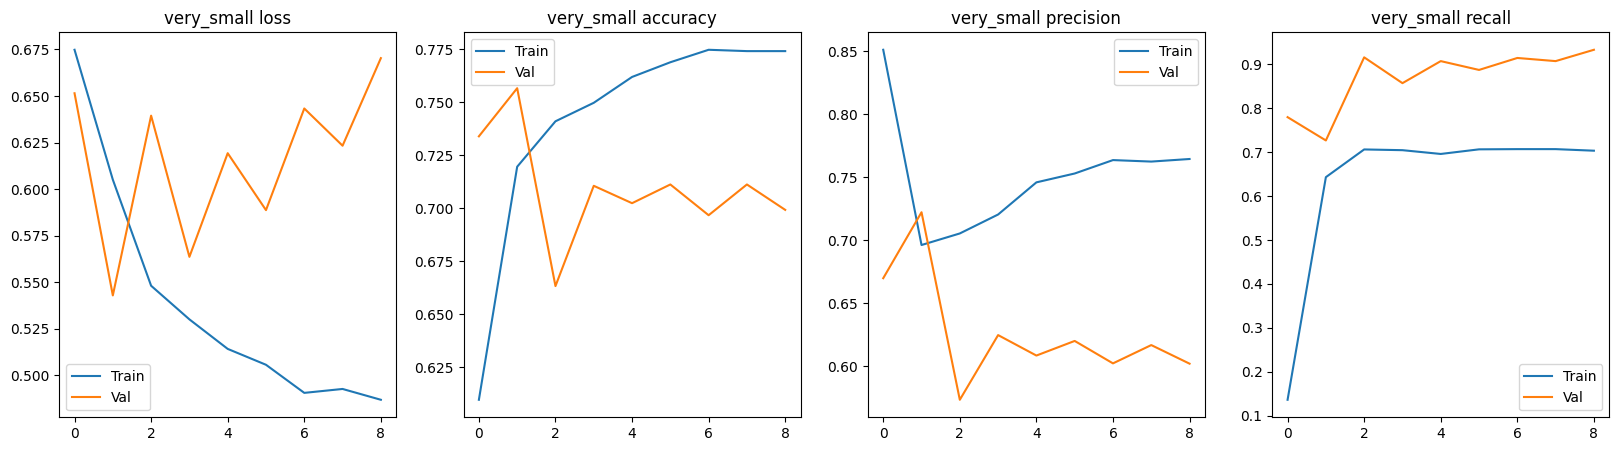


--- TESTING BINARY SMALL ---
Epoch 1/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.6580 - loss: 0.6336 - precision: 0.7075 - recall: 0.3791 - val_accuracy: 0.6393 - val_loss: 0.6558 - val_precision: 0.5528 - val_recall: 0.9456 - learning_rate: 1.0000e-04
Epoch 2/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.7660 - loss: 0.5033 - precision: 0.7582 - recall: 0.6871 - val_accuracy: 0.7137 - val_loss: 0.5512 - val_precision: 0.6266 - val_recall: 0.8653 - learning_rate: 1.0000e-04
Epoch 3/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.7723 - loss: 0.4886 - precision: 0.7722 - recall: 0.6842 - val_accuracy: 0.7169 - val_loss: 0.5663 - val_precision: 0.6210 - val_recall: 0.9155 - learning_rate: 1.0000e-04
Epoch 4/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.7916 - loss: 0.4635 - precision: 0.7913 - recall: 0.7145 - val_accuracy: 0.7182 - val_loss: 0.5622 - val_precision: 0.6203 - val_recall: 0.9269 - learning_rate: 5.0000e-05
Epoch 5/30
298

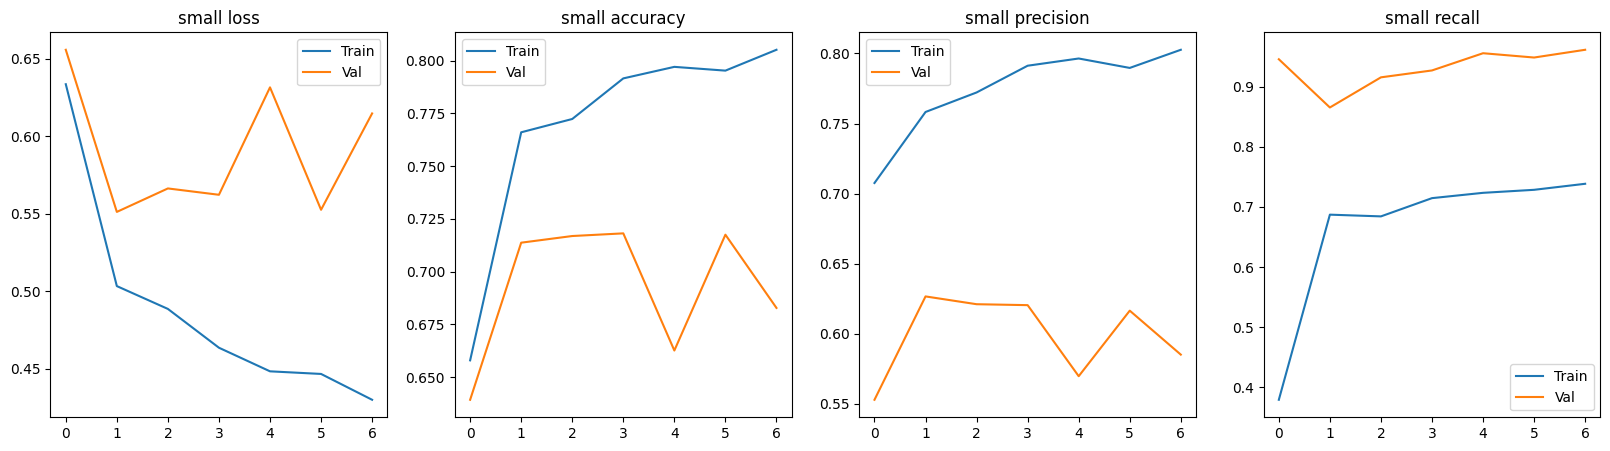


--- TESTING BINARY MEDIUM ---
Epoch 1/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.6765 - loss: 0.6015 - precision: 0.7448 - recall: 0.4023 - val_accuracy: 0.5530 - val_loss: 0.9032 - val_precision: 0.4960 - val_recall: 0.9713 - learning_rate: 1.0000e-04
Epoch 2/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.7699 - loss: 0.4889 - precision: 0.7808 - recall: 0.6629 - val_accuracy: 0.5290 - val_loss: 1.0226 - val_precision: 0.4828 - val_recall: 0.9871 - learning_rate: 1.0000e-04
Epoch 3/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.7932 - loss: 0.4538 - precision: 0.7932 - recall: 0.7167 - val_accuracy: 0.4653 - val_loss: 1.1660 - val_precision: 0.4515 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.8113 - loss: 0.4202 - precision: 0.7989 - recall: 0.7630 - val_accuracy: 0.4987 - val_loss: 1.2362 - val_precision: 0.4672 - val_recall: 0.9900 - learning_rate: 5.0000e-05
Epoch 5/30
2

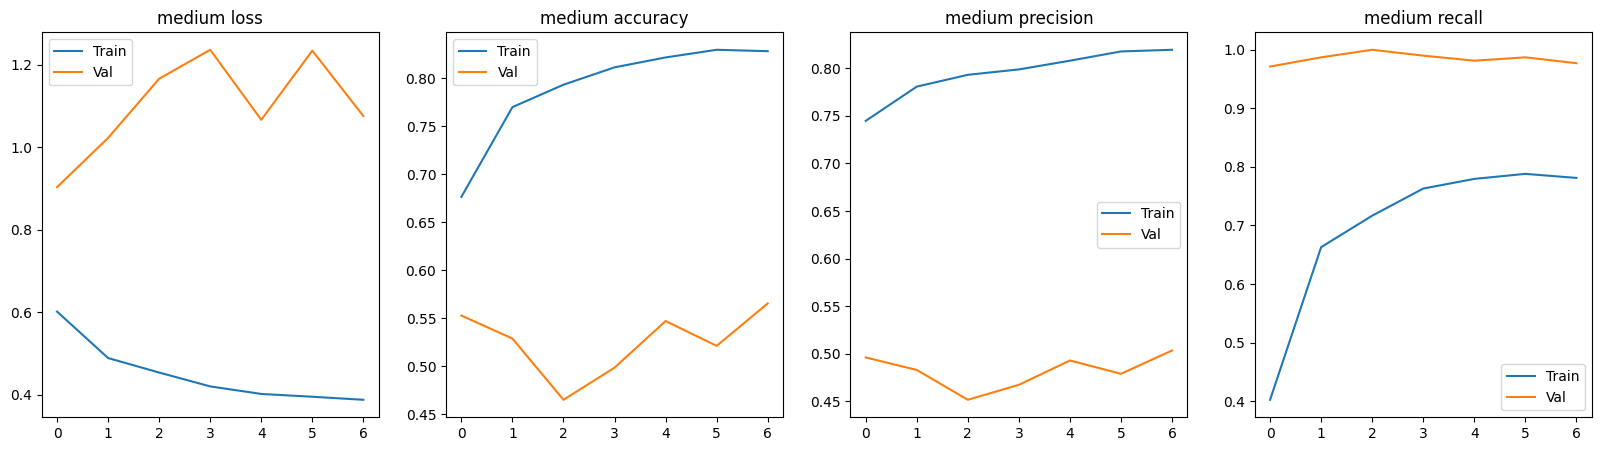


--- TESTING BINARY LARGE ---
Epoch 1/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 30s 95ms/step - accuracy: 0.7090 - loss: 0.5661 - precision: 0.7567 - recall: 0.4986 - val_accuracy: 0.6879 - val_loss: 0.5858 - val_precision: 0.6012 - val_recall: 0.8639 - learning_rate: 1.0000e-04
Epoch 2/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 28s 94ms/step - accuracy: 0.7927 - loss: 0.4540 - precision: 0.8041 - recall: 0.6990 - val_accuracy: 0.5290 - val_loss: 1.1604 - val_precision: 0.4829 - val_recall: 0.9885 - learning_rate: 1.0000e-04
Epoch 3/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 28s 94ms/step - accuracy: 0.8230 - loss: 0.4067 - precision: 0.8132 - recall: 0.7757 - val_accuracy: 0.7043 - val_loss: 0.6489 - val_precision: 0.6032 - val_recall: 0.9585 - learning_rate: 1.0000e-04
Epoch 4/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 28s 94ms/step - accuracy: 0.8382 - loss: 0.3825 - precision: 0.8311 - recall: 0.7934 - val_accuracy: 0.6929 - val_loss: 0.6343 - val_precision: 0.5938 - val_recall: 0.9570 - learning_rate: 5.0000e-05
Epoch 5/30

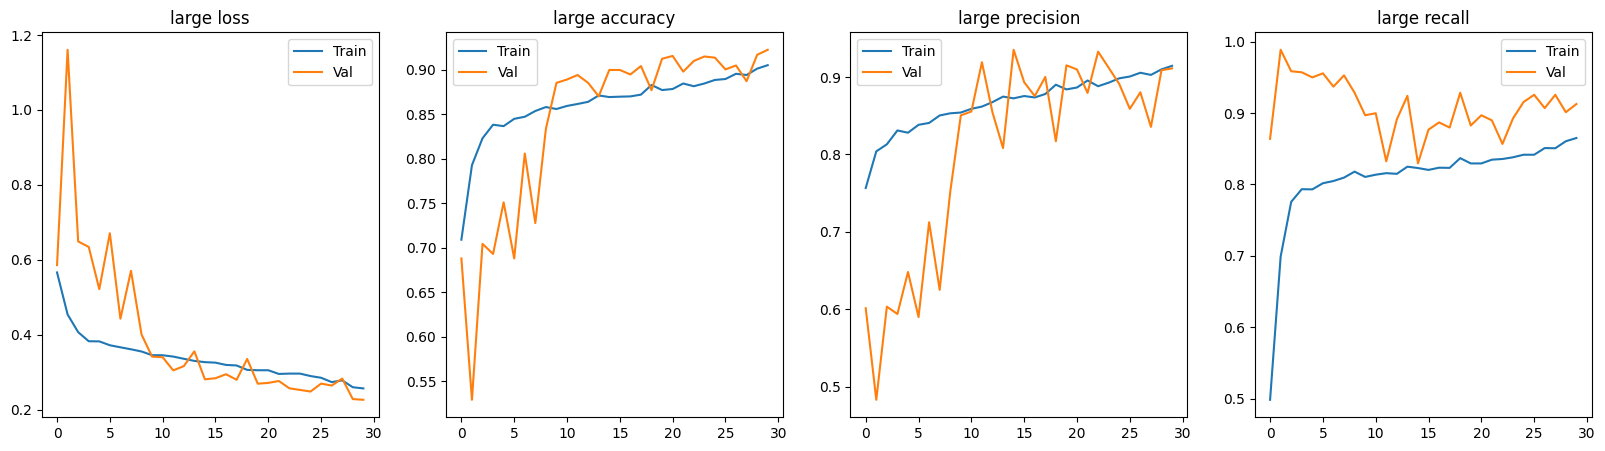

In [ ]:
# defining the loss functions and callbacks
my_loss = focal_loss(gamma=2.0, alpha=0.25)
my_callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
]

# running experiments with focal loss and class weights for different model sizes
all_results = {}
for model_size in ['very_small', 'small', 'medium', 'large']:
    all_results[model_size] = run_binary_experiment(model_size, my_loss, class_weights, my_callbacks)

# running experiments without class weights to see the impact of class weighting on model performance
all_results_no_weights = {}
for model_size in ['very_small', 'small', 'medium', 'large']:
    all_results_no_weights[model_size] = run_binary_experiment(
        model_size, 'binary_crossentropy', None, my_callbacks
    )

# downsampling the training set
bal_tr_p, bal_tr_l = balance_split(tr_p, tr_l)
balanced_train_ds = (
    tf.data.Dataset.from_tensor_slices((bal_tr_p, bal_tr_l))
    .shuffle(len(bal_tr_p))
    .map(load_and_preprocess)
    .map(augment)
    .batch(Batch)
    .prefetch(tf.data.AUTOTUNE)
)

orig_train_ds = train_ds
train_ds = balanced_train_ds

# running experiments with balanced dataset and binary cross entropy loss for different model sizes
all_results_downsample = {}
for model_size in ['very_small', 'small', 'medium', 'large']:
    all_results_downsample[model_size] = run_binary_experiment(
        model_size, 'binary_crossentropy', None, my_callbacks
    )

train_ds = orig_train_ds

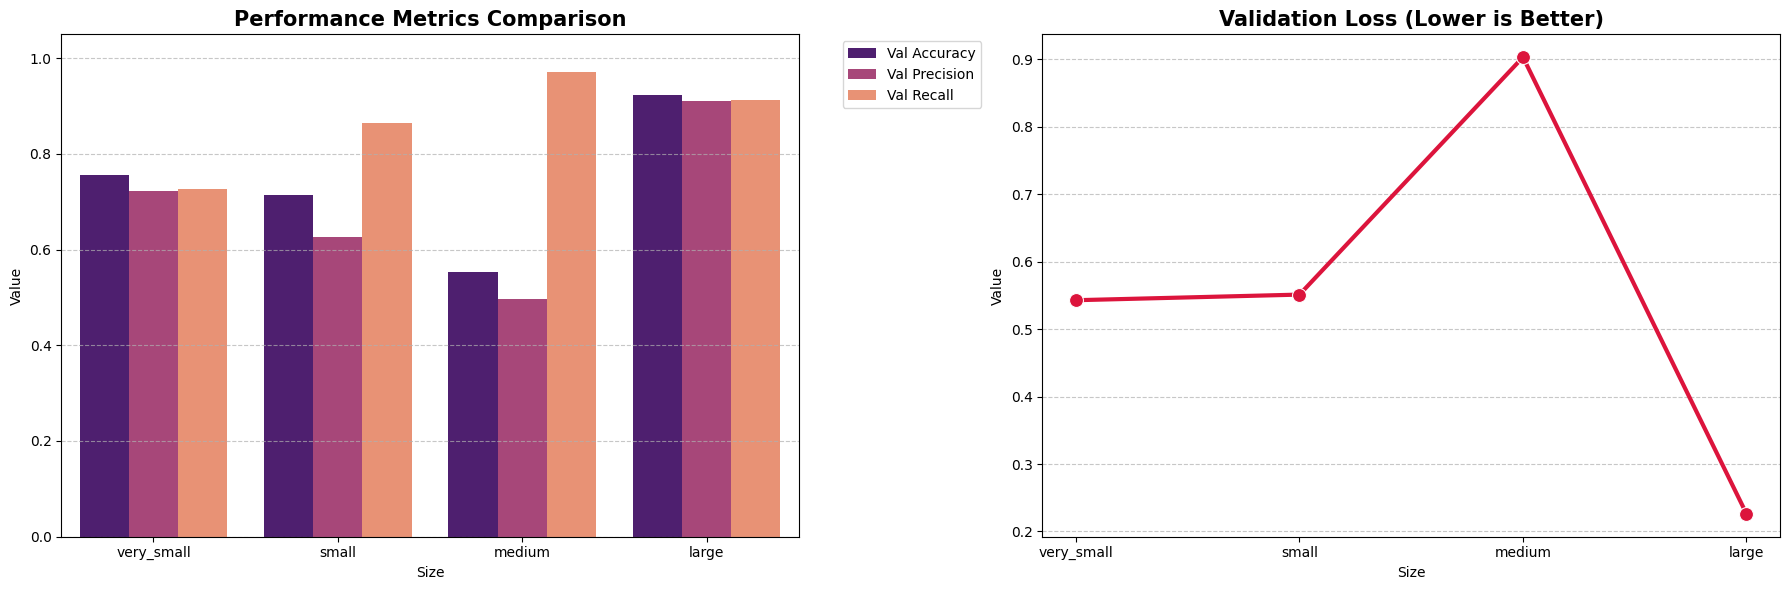

In [ ]:
# plotting the variouys model comparisons
plot_model_comparison(all_results)
plot_model_comparison(all_results_no_weights)
plot_model_comparison(all_results_downsample)

Comparing all the graphs, the minor imbalance of the dataset for the binary task is shown. 

### EfficientNetV2 comparison

Having found good hyperparameter sizes, along with justifying the various compiling methods. I will now compare my hand tuned model to a industry standard, EfficientNetV2. Ive based this model around the same size as the medium model. I will run the function below which builds said model and compares it the previously made models above.

In [ ]:
def build_effnet_binary_model(loss_fn=None):
    ''' Build a binary classification model using EfficientNetV2B0 as the base architecture, with optional loss function.'''

    inputs = keras.layers.Input(shape=(96, 96, 3))
    x = keras.layers.Lambda(lambda tensor: tensor * 255.0)(inputs)

    # load the EfficientNetV2B0 model without the top classification layer
    base_model = keras.applications.EfficientNetV2B0(
        include_top=False,
        weights='imagenet',
        input_tensor=x,
        input_shape=(96, 96, 3)
    )
    
    base_model.trainable = True
    # add custom classification head on top of the base model
    x = base_model.output
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dense(16, activation='relu')(x)
    x = keras.layers.Dropout(0.2)(x)
    outputs = keras.layers.Dense(1, activation='sigmoid')(x)

    model = keras.models.Model(inputs, outputs)
    # compiling the model with the given loss function
    model.compile(
        optimizer=keras.optimizers.Adam(1e-4),
        loss=loss_fn if loss_fn else 'binary_crossentropy',
        metrics=[
            'accuracy', 
            keras.metrics.Precision(name='precision'), 
            keras.metrics.Recall(name='recall')
        ]
    )
    return model

# running experiments with focal loss and class weights for EfficientNetV2B0
print("\n--- TESTING EFFICIENTNETV2B0 (BINARY) ---")
effnet_bin_model = build_effnet_binary_model(my_loss)

history_effnet_bin = effnet_bin_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weights,
    callbacks=my_callbacks,
    verbose=1
)

all_results['EfficientNetV2'] = (effnet_bin_model, history_effnet_bin)

plot_model_comparison(all_results)


--- TESTING EFFICIENTNETV2B0 (BINARY) ---

Epoch 1/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 70s 167ms/step - accuracy: 0.8181 - loss: 0.0253 - precision: 0.8044 - recall: 0.7750 - val_accuracy: 0.9224 - val_loss: 0.0111 - val_precision: 0.9055 - val_recall: 0.9198 - learning_rate: 1.0000e-04
Epoch 2/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 47s 156ms/step - accuracy: 0.9245 - loss: 0.0123 - precision: 0.9172 - recall: 0.9104 - val_accuracy: 0.9741 - val_loss: 0.0056 - val_precision: 0.9646 - val_recall: 0.9771 - learning_rate: 1.0000e-04
Epoch 3/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 47s 157ms/step - accuracy: 0.9509 - loss: 0.0087 - precision: 0.9448 - recall: 0.9436 - val_accuracy: 0.9754 - val_loss: 0.0044 - val_precision: 0.9714 - val_recall: 0.9728 - learning_rate: 1.0000e-04
Epoch 4/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 47s 156ms/step - accuracy: 0.9609 - loss: 0.0069 - precision: 0.9532 - recall: 0.9582 - val_accuracy: 0.9836 - val_loss: 0.0030 - val_precision: 0.9773 - val_recall: 0.9857 - learning_rate: 1.0

KeyboardInterrupt: 

The EfficientNetV2, as expected of a industry standard, performs better and more accurately than my hand tuned models of its comparative hyperparameter size. This does however come with a significant  time penalty. For areas in climate science where accurate prediction is key this could be a reasonable tradeoff. however for the total runtime of 1 minute on my local machine the 'very small' model with image hashed and downsampled data performs very well for its size and complexity.

### Finding the optimal model

To find the most optimal hand tuned model possible, I employ the Keras tuner library to run through iterations of my models and present the best combination

In [ ]:
def build_tuning_model(hp):
    ''' Build a binary classification model with hyperparameters for 
    tuning using Keras Tuner.'''
    base_filters = 8

    # building the model 
    model = keras.models.Sequential()
    model.add(keras.layers.Input(shape=(96, 96, 3)))
    
    # looping through convolutional blocks with hyperparameters 
    for i in range(2): 
        filters = base_filters * (2**i)
        model.add(keras.layers.Conv2D(filters, 3, activation='relu', padding='same'))
        model.add(keras.layers.MaxPooling2D())
        
        hp_dropout_conv = hp.Float(f'dropout_{i}', min_value=0.1, max_value=0.3, step=0.1)
        model.add(keras.layers.Dropout(hp_dropout_conv))

    model.add(keras.layers.Conv2D(filters * 2, 3, activation='relu', padding='same'))
    model.add(keras.layers.GlobalAveragePooling2D())
    
    # adding a dense layer with hyperparameter for number of units and dropout
    hp_dense_units = hp.Int('dense_units', min_value=16, max_value=64, step=16)
    model.add(keras.layers.Dense(hp_dense_units, activation='relu'))
    model.add(keras.layers.Dropout(0.2))
    model.add(keras.layers.Dense(1, activation='sigmoid')) 

    hp_learning_rate = hp.Choice('learning_rate', values=[1e-3, 1e-4, 1e-5])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
        loss=focal_loss(gamma=2.0, alpha=0.25),
        metrics=['accuracy', keras.metrics.Precision(name='precision'), keras.metrics.Recall(name='recall')]
    )
    return model
# setting up Keras Tuner with Hyperband for hyperparameter tuning of the small model architecture
tuner = kt.Hyperband(
    build_tuning_model,
    objective='val_accuracy',
    max_epochs=15,
    factor=3,
    directory='hyperband_small_model',
    project_name='fire_small_tuning'
)

stop_early = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

# running the hyperparameter search 
tuner.search(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[stop_early],
    class_weight=class_weights
)

# retrieving the best hyperparameters and training the final model with those hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best Dense Units: {best_hps.get('dense_units')}")
print(f"Best Learning Rate: {best_hps.get('learning_rate')}")

final_model = tuner.hypermodel.build(best_hps)
history = final_model.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=30, 
    class_weight=class_weights
)

# model type, conv vs seperable conv

In [ ]:
def build_small_comparison(use_separable=False):
    
    model = keras.models.Sequential()
    model.add(keras.layers.Input(shape=(96, 96, 3)))
    
    LayerType = keras.layers.SeparableConv2D if use_separable else keras.layers.Conv2D
    
    model.add(LayerType(8, 3, activation='relu', padding='same'))
    model.add(keras.layers.MaxPooling2D())
    model.add(keras.layers.Dropout(0.2))
    
    model.add(LayerType(16, 3, activation='relu', padding='same'))
    model.add(keras.layers.MaxPooling2D())
    model.add(keras.layers.Dropout(0.2))

    model.add(LayerType(32, 3, activation='relu', padding='same'))
    model.add(keras.layers.GlobalAveragePooling2D())
    model.add(keras.layers.Dense(16, activation='relu'))
    model.add(keras.layers.Dropout(0.2))
    model.add(keras.layers.Dense(1, activation='sigmoid')) 

    model.compile(optimizer=keras.optimizers.Adam(1e-4), loss='binary_crossentropy', metrics=['accuracy'])
    return model

std_model = build_small_comparison(use_separable=False)
sep_model = build_small_comparison(use_separable=True)

print(f"{'Model Type':<20} | {'Total Parameters':<20}")
print("-" * 45)
print(f"{'Standard Conv2D':<20} | {std_model.count_params():<20,}")
print(f"{'Separable Conv2D':<20} | {sep_model.count_params():<20,}")

reduction = (1 - sep_model.count_params() / std_model.count_params()) * 100
print(f"\nParameter Reduction: {reduction:.2f}%")

### Conclusion

In this notebook, I used the pre processed and cleaned data to test for the best hand tuned model possible. In the process I compared varied data processing methods, while implementing modern machine learning techniques like class weights and callbacks. This resulted in a bundle of varying size and efficiency models. After review and discussion there is a strong case that my smallest 7k parameter model performs the best given the time complexity of the larger models, including EfficientNetV2 which performed the best while taking 10x longer than the 'very small' model.

I also quickly demonstrated the best hyperparameters possible using keras tuner, and demonstrated the difference in performance when using seperable Convolution layers instead of convolution layers from which I concluding that while the seperable layers where much faster, the trade off in performance is not worth it.
